## Initialization

In [1]:
from torch.func import vjp
import torch
from torch.func import jacrev, functional_call
import torch.nn as nn
from torch import Tensor

import torch.nn.functional as F

import sys
import os

from collections import defaultdict
from typing import Callable, Dict, Any, List


current_notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root_dir = os.path.abspath(os.path.join(current_notebook_dir, '../../'))

# 将这个父目录添加到sys.path的最前面
if project_root_dir not in sys.path:
    sys.path.insert(0, project_root_dir)

print(sys.path)

['/home/hqdeng7/lijuyang/generalization', '/home/hqdeng7/.conda/envs/ljy/lib/python311.zip', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11/lib-dynload', '', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11/site-packages']


In [2]:
from loss_distribution.pytorch_script.visual_utils \
	import load_cifar10_data, load_model_state_dict

from ntk_result.trials.utils import *


import torchvision
import torchvision.transforms as transforms

data_pth = '/home/hqdeng7/lijuyang/generalization/loss_distribution/pytorch_script/data/cifar10'
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
train_ds = torchvision.datasets.CIFAR10(root=data_pth, train=True, download=True, transform=transform)
test_ds = torchvision.datasets.CIFAR10(root=data_pth, train=False, download=True, transform=transform)

In [3]:
model200_path = '/home/hqdeng7/lijuyang/generalization/loss_distribution/model_training_results/cifar10_resnet20/model_200.pth'
model200 = load_model_state_dict('cifar10', 'resnet20', 10, model200_path, 'cuda')
model100_path = '/home/hqdeng7/lijuyang/generalization/loss_distribution/model_training_results/cifar10_resnet20/model_100.pth'
model100 = load_model_state_dict('cifar10', 'resnet20', 10, model100_path, 'cuda')

  从字典中提取模型状态字典...
提取成功
  从字典中提取模型状态字典...
提取成功


In [4]:
def evaluate_model(model, dataloader, device='cuda'):
	model.to(device)
	model.eval()
	total_loss = 0.0
	correct = 0
	total = 0
	criterion = nn.CrossEntropyLoss()
	with torch.no_grad():
		for inputs, targets in dataloader:
			inputs, targets = inputs.to(device), targets.to(device)
			outputs = model(inputs)
			loss = criterion(outputs, targets)
			total_loss += loss.item() * inputs.size(0)
			_, predicted = outputs.max(1)
			correct += predicted.eq(targets).sum().item()
			total += targets.size(0)
	avg_loss = total_loss / total
	acc = correct / total
	return avg_loss, acc


In [5]:
from torch.optim import SGD

def train_one_batch(model, batch, optimizer):
	model.train()
	criterion = nn.CrossEntropyLoss()

	inputs, targets = batch
	inputs, targets = inputs.cuda(), targets.cuda()

	optimizer.zero_grad()
	outputs = model(inputs)
	loss = criterion(outputs, targets)
	loss.backward()
	optimizer.step()

	print(f"One training step done. Loss: {loss.item():.4f}")

In [6]:
from torch.utils.data import Subset, DataLoader

train_subdl = DataLoader(train_ds, batch_size=512)
test_dl = DataLoader(test_ds, batch_size=512)

train_loss0, train_acc0 = evaluate_model(model100, train_subdl)
test_loss0, test_acc0 = evaluate_model(model100, test_dl)

In [7]:
from torch.utils.data import Subset, DataLoader
from loss_distribution.pytorch_script.models import get_model
import random
import io
import contextlib

In [8]:
def set_seed(seed):
    """设置随机种子以确保实验可复现"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    
    # 以下两项是针对cuDNN的设置
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # 设置环境变量，进一步增强确定性
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'


def seed_worker(worker_id):
    """
    为每个Dataloader worker设置独立的种子。
    这对于可复现的数据增强非常重要。
    """
    worker_seed = torch.initial_seed()
    
    # 2. 为 numpy 设置种子
    np.random.seed(worker_seed + worker_id)
    
    # 3. 为 random 设置种子
    random.seed(worker_seed + worker_id)

## continueTrain

### one cluster continue

In [ ]:
test_indices = np.load('cls30_indices_arrs.npz')['arr0']

In [ ]:
train_subdl = DataLoader(train_ds, batch_size=512)
test_dl = DataLoader(test_ds, batch_size=512)

train_subds = Subset(train_ds, train_indices)
train_subdl = DataLoader(train_subds, batch_size=512)

test_subds = Subset(test_ds, test_indices)
test_subdl = DataLoader(test_subds, batch_size=512)

train_loss0, train_acc0 = evaluate_model(model100, train_subdl)
test_loss0, test_acc0 = evaluate_model(model100, test_dl)
test_sub_loss0, test_sub_acc0 = evaluate_model(model100, test_subdl)

In [ ]:
print("Original loss/acc")
print(f"train loss: {train_loss0:.4f}, train acc: {train_acc0:.4f}")
print(f"test loss: {test_loss0:.4f}, test acc: {test_acc0:.4f}")
print(f"sub test loss: {test_sub_loss0:.4f}, sub test acc: {test_sub_acc0:.4f}")

In [ ]:
model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
train_one_batch(model, next(iter(train_subdl)), optimizer)

In [ ]:
print(evaluate_model(model100, train_subdl))

In [ ]:
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

In [ ]:
print("After training one cls30 cluster")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

In [ ]:
print("Original loss/acc")
print(f"train loss: {train_loss0:.4f}, train acc: {train_acc0:.4f}")
print(f"test loss: {test_loss0:.4f}, test acc: {test_acc0:.4f}")
print(f"sub test loss: {test_sub_loss0:.4f}, sub test acc: {test_sub_acc0:.4f}")

### one cluster + random

In [ ]:
train_sub_indices_arrs = np.load('train_indices.npy')
train_sub_indices = np.reshape(train_sub_indices_arrs, (-1,))

test_sub_indices_arrs = 

train_subds = Subset(train_ds, train_sub_indices)
train_subds = Subset(train_ds, train_indices)

test_subds = Subset(test_ds, test_indices)
test_subdl = DataLoader(test_subds, batch_size=512)

In [ ]:
orig_indices = train_subds.indices
num_random = len(orig_indices) * 10
random_indices = np.random.choice(np.array(range(len(train_ds))), size=num_random, replace=False)

combined_indices = np.concatenate([orig_indices, random_indices])

bigger_train_subds = Subset(train_ds, combined_indices)
bigger_train_subdl = DataLoader(bigger_train_subds, batch_size=512, shuffle=True)

In [ ]:
model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

for batch in bigger_train_subdl:
	train_one_batch(model, batch, optimizer)

In [ ]:
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

In [ ]:
print("After training one cls30 + random")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

In [ ]:
test_sub_loss0, test_sub_acc0 = evaluate_model(model100, test_subdl)
print("Original loss/acc")
print(f"train loss: {train_loss0:.4f}, train acc: {train_acc0:.4f}")
print(f"test loss: {test_loss0:.4f}, test acc: {test_acc0:.4f}")
print(f"sub test loss: {test_sub_loss0:.4f}, sub test acc: {test_sub_acc0:.4f}")

### cls10 one cluster + random

In [ ]:
test_indices = np.load('cls10_indices_arrs.npz', allow_pickle=True)['arr_0']
train_indices = np.load('cls10_train_indices_arrs.npy')[0]

In [ ]:
train_subds = Subset(train_ds, train_indices)

test_subds = Subset(test_ds, test_indices)
test_subdl = DataLoader(test_subds, batch_size=512)

In [ ]:
orig_indices = train_subds.indices
num_random = len(orig_indices) * 10
random_indices = np.random.choice(np.array(range(len(train_ds))), size=num_random, replace=False)

combined_indices = np.concatenate([orig_indices, random_indices])

bigger_train_subds = Subset(train_ds, combined_indices)
bigger_train_subdl = DataLoader(bigger_train_subds, batch_size=512, shuffle=True)

In [ ]:
model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

for batch in bigger_train_subdl:
	train_one_batch(model, batch, optimizer)

for batch in bigger_train_subdl:
	train_one_batch(model, batch, optimizer)

In [ ]:
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

In [ ]:
print("After trainig one cls10 cluster + random samples")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

In [ ]:
test_sub_loss0, test_sub_acc0 = evaluate_model(model100, test_subdl)
print("Original loss/acc")
print(f"train loss: {train_loss0:.4f}, train acc: {train_acc0:.4f}")
print(f"test loss: {test_loss0:.4f}, test acc: {test_acc0:.4f}")
print(f"sub test loss: {test_sub_loss0:.4f}, sub test acc: {test_sub_acc0:.4f}")

### all clusters continue

#### preparation

In [ ]:
data = np.load("filtered_cls30_indices_arrs.npz", allow_pickle=True)
filtered_cls30_indices_arrs = [data[f"arr_{i}"] for i in range(len(data.files))]

train_indices_arrs = np.load('train_indices_arrs.npy')
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)
train_subdl = DataLoader(train_subds, batch_size=512)

test_sub_indices = np.concatenate(filtered_cls30_indices_arrs)
test_subds = Subset(test_ds, test_sub_indices)
test_subdl = DataLoader(test_subds, batch_size=512)

In [ ]:
test_sub_loss0, test_sub_acc0 = evaluate_model(model100, test_subdl)
print("Original loss/acc")
print(f"train loss: {train_loss0:.4f}, train acc: {train_acc0:.4f}")
print(f"test loss: {test_loss0:.4f}, test acc: {test_acc0:.4f}")
print(f"sub test loss: {test_sub_loss0:.4f}, sub test acc: {test_sub_acc0:.4f}")

In [ ]:
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed) 
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#### in order

In [ ]:
model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
for train_indices in train_indices_arrs:
	train_subds = Subset(train_ds, train_indices)
	train_subdl = DataLoader(train_subds, batch_size=512)
	train_one_batch(model, next(iter(train_subdl)), optimizer)


In [ ]:
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

In [ ]:
print("After training clusters in order")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

In [ ]:
import torch
torch.cuda.empty_cache()

#### shuffle

In [ ]:
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)
train_subdl = DataLoader(train_subds, batch_size=512, shuffle=True)

model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
for batch in train_subdl:
	train_one_batch(model, batch, optimizer)


In [ ]:
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

In [ ]:
print("After training clusters with shuffle")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

#### all clusters + random

In [ ]:
orig_indices = train_subds.indices
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)
train_subdl = DataLoader(train_subds, batch_size=512, shuffle=True)

num_random = len(orig_indices) * 4

random_indices = np.random.choice(np.array(range(len(train_ds))), size=num_random, replace=False)

combined_indices = np.concatenate([orig_indices, random_indices])
bigger_train_subds = Subset(train_ds, combined_indices)
bigger_train_subdl = DataLoader(bigger_train_subds, batch_size=512, shuffle=True)

In [ ]:
num_random + len(orig_indices)

In [ ]:
model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

for batch in bigger_train_subdl:
	with contextlib.redirect_stdout(io.StringIO()):
		train_one_batch(model, batch, optimizer)

In [ ]:
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

In [ ]:
print("After training shuffled cls30 + random samples")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

In [ ]:
test_sub_loss0, test_sub_acc0 = evaluate_model(model100, test_subdl)
print("Original loss/acc")
print(f"train loss: {train_loss0:.4f}, train acc: {train_acc0:.4f}")
print(f"test loss: {test_loss0:.4f}, test acc: {test_acc0:.4f}")
print(f"sub test loss: {test_sub_loss0:.4f}, sub test acc: {test_sub_acc0:.4f}")

#### cls15 + random

In [ ]:
test_indices = np.load('cls10_indices_arrs.npz', allow_pickle=True)['arr_0']
train_indices_arrs = np.load('cls10_train_indices_arrs.npy')
train_indices = np.reshape(train_indices_arrs, (-1,))

train_subds = Subset(train_ds, train_indices)
train_subdl = DataLoader(train_subds, batch_size=512, shuffle=True)

orig_indices = train_subds.indices
num_random = len(orig_indices) * 6
random_indices = np.random.choice(np.array(range(len(train_ds))), size=num_random, replace=False)

combined_indices = np.concatenate([orig_indices, random_indices])
bigger_train_subds = Subset(train_ds, combined_indices)
bigger_train_subdl = DataLoader(bigger_train_subds, batch_size=512, shuffle=True)

model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
for batch in bigger_train_subdl:
	train_one_batch(model, batch, optimizer)

for batch in bigger_train_subdl:
	train_one_batch(model, batch, optimizer)

train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

print("After training shuffled cls15 + random samples")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

## contrast

### one epoch

In [ ]:
seed_value = 42
set_seed(seed_value)

model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

data = np.load("filtered_cls30_indices_arrs.npz", allow_pickle=True)
filtered_cls30_indices_arrs = [data[f"arr_{i}"] for i in range(len(data.files))]

test_sub_indices = np.concatenate(filtered_cls30_indices_arrs)
test_subds = Subset(test_ds, test_sub_indices)
test_subdl = DataLoader(test_subds, batch_size=512)

lr = 0.05
optimizer = SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

for batch in train_subdl:
	with contextlib.redirect_stdout(io.StringIO()):
		train_one_batch(model, batch, optimizer)

train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

print("After training one epoch")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

#### 5 epochs

In [ ]:
import io
import contextlib

model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

for i in range(5):
	for batch in train_subdl:
		with contextlib.redirect_stdout(io.StringIO()):
			train_one_batch(model, batch, optimizer)

train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

print("After training one epoch")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

In [ ]:
test_indices = np.load('cls10_indices_arrs.npz', allow_pickle=True)['arr_0']
train_indices_arrs = np.load('cls30_train_indices_arrs.npy')
train_indices = np.reshape(train_indices_arrs, (-1,))

train_subds = Subset(train_ds, train_indices)
train_subdl = DataLoader(train_subds, batch_size=512, shuffle=True)

orig_indices = train_subds.indices
num_random = len(orig_indices) * 6
random_indices = np.random.choice(np.array(range(len(train_ds))), size=num_random, replace=False)

combined_indices = np.concatenate([orig_indices, random_indices])
bigger_train_subds = Subset(train_ds, combined_indices)
bigger_train_subdl = DataLoader(bigger_train_subds, batch_size=512, shuffle=True)

model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
for i in range(5):
	for batch in bigger_train_subdl:
		with contextlib.redirect_stdout(io.StringIO()):
			train_one_batch(model, batch, optimizer)

train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

print("After training shuffled cls15 + random samples")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

### naive hard example mining

In [ ]:
from torch.utils.data import Subset, DataLoader

# Find top 1000 high-loss samples from the training set
topk = 1000
batch_loss_fn = get_batch_loss_fn(model100)
high_loss_indices = list(zip(*find_topk_samples(train_ds, batch_loss_fn, k=topk)))[1]

# Create DataLoader for high-loss samples
high_loss_subds = Subset(train_ds, high_loss_indices)
high_loss_subdl = DataLoader(high_loss_subds, batch_size=512, shuffle=True)

In [ ]:
# Re-initialize new_model from model100
model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
for batch in high_loss_subdl:
	train_one_batch(model, batch, optimizer)

# Evaluate and print results
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

print("After training on high-loss samples")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")

In [ ]:
len(high_loss_subdl)

### online hard example mining

In [ ]:
import torch.nn.functional as F

def train_one_epoch_ohem(model, dataloader, optimizer, device, top_k_ratio=0.5):
    """
    Args:
        model: nn.Module
        dataloader: DataLoader
        optimizer: torch.optim
        device: 'cuda' or 'cpu'
        top_k_ratio: 选取 batch 内 top-k 样本的比例 (0~1)
    """
    model.train()
    criterion = nn.CrossEntropyLoss(reduction='none')  # 不要平均，返回每个样本的 loss

    total_loss, total_correct, total_seen = 0, 0, 0

    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        # 逐样本 loss
        losses = criterion(outputs, targets)  # shape: (batch_size,)
        
        # 选取 batch 内 top-k
        batch_size = losses.shape[0]
        k = max(1, int(batch_size * top_k_ratio))  # 至少要有1个
        topk_loss, topk_idx = torch.topk(losses, k)

        # 只对 hardest k 个样本反传
        topk_loss.mean().backward()
        optimizer.step()

        # 统计
        preds = outputs.argmax(dim=1)
        total_correct += (preds == targets).sum().item()
        total_seen += batch_size
        total_loss += topk_loss.sum().item()  # 累加 hard 样本 loss

    avg_loss = total_loss / total_seen
    avg_acc = total_correct / total_seen
    return avg_loss, avg_acc

In [ ]:
model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
train_one_epoch_ohem(model, train_subdl, optimizer, "cuda", top_k_ratio=1)

# Evaluate and print results
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

print("After online hard example mining")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")

## not to train

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.func import functional_call, vmap, grad  # grad 在较新 torch.func 中可用
from torch.utils.data import DataLoader
import heapq
from functorch import make_functional_with_buffers

from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans

def cluster_and_get_centroids(data, n_clusters: int):
	kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
	kmeans.fit(data)

	return kmeans.labels_, kmeans.cluster_centers_


def find_closest_samples(samples, center):
	# 计算该聚类中所有样本到其中心点的距离
	distances = cdist(samples, [center], 'euclidean').flatten()
	
	# 找到最小距离及其对应的样本索引
	min_dist_idx = np.argmin(distances)
	
	return min_dist_idx

X_pca = np.load('X_pca.npy')
cls30_labels, cls30_centers = cluster_and_get_centroids(X_pca, 30)


def get_param_jac(model, inputs, device="cuda"):

	model.eval()
	inputs = inputs.to(device)
	params = dict(model.named_parameters())
	buffers = dict(model.named_buffers())

	def grad_fn(params, input, class_idx):
		def loss_fn(params):
			out = functional_call(model, (params, buffers), input.unsqueeze(0))  # (1, C)
			oh = torch.zeros_like(out)  # (1, C)
			oh = oh.scatter(1, class_idx.view(1,1), 1.0)  # out-of-place, safe for vmap
			return (out[0] * oh).sum()  # 标量
		grads = grad(loss_fn)(params)
		return grads  # tuple of param-shaped grads
	
	class_idxs = torch.arange(10, device=device)

	def per_sample_jac(input):
		grads_per_class = vmap(lambda c: grad_fn(params, input, c))(class_idxs)
		# grads_per_class: tuple of tensors, each (C, *param_shape)
		flat = []
		for g in grads_per_class.values():  # over params
			flat.append(g.reshape(g.shape[0], -1))  # (C, param_dim)
		return torch.cat(flat, dim=1)  # (C, P)

	# vmap over batch
	jacobian = vmap(per_sample_jac)(inputs)  # (B, C, P)
	return jacobian


# ---------- get_batch_myentk_fn：名称、接口与原来一致，但内部使用更快的 get_param_jac（按块） ----------
def get_batch_myentk_fn(model, 
						ref_input,
						ref_label,
						loss_fn=nn.CrossEntropyLoss(reduction='none'), 
						device='cuda'):
	model.eval()
	loss_fn = loss_fn if loss_fn.reduction == 'none' else type(loss_fn)(reduction='none')
	model = model.to(device)

	ref_input = ref_input.unsqueeze(0)
	ref_input = ref_input.to(device)

	# 用我们优化后的 get_param_jac（它内部会把 model functionalize 并缓存）
	ref_jacob = get_param_jac(model, ref_input, device=device)  # (1, out_dim, P)

	# 构造左向量（与原实现一致）
	t = torch.full((ref_jacob.shape[1],), -1, device=device)
	t[ref_label] = 1
	left_mat = ref_jacob * t.view(1, -1, 1)  # (1, out_dim, P)
	left_mat = torch.sum(left_mat.squeeze(0), 0)  # (P,)

	def batch_myentk_fn(batch):
		inputs, labels = batch
		inputs = inputs.to(device)
		labels = labels.to(device)

		# 计算 batch 的 jacob（按块）
		jacobs = get_param_jac(model, inputs, device=device)  # (B, out_dim, P)
		right_mat = jacobs[torch.arange(len(inputs)), labels]  # (B, P)

		results = right_mat.mv(left_mat)  # (B,)
		return results  # 保持 tensor 返回（跟你原来代码的返回类型一致）
	
	return batch_myentk_fn

# ---------- find_topk_samples：名字与原来一致，但内部用向量化 topk 合并以加速 ----------
def find_topk_samples(
	ds, 
	fn,
	k=16,
	batch_size=256,
	reverse=False,
	show_progress=True,
	num_workers=4,
	pin_memory=True
):
	"""
	返回 list of (value, idx) 与原来接口相同。
	优化：使用 torch.topk 在 CPU/Tensor 上流式合并 top-k，避免 Python 层 per-sample heap 操作。
	"""
	dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
	best_vals = None  # tensor
	best_idxs = None
	idx_offset = 0

	iterator = dl
	if show_progress:
		iterator = tqdm(dl)

	for batch in iterator:
		batch_res = fn(batch)  # 假设返回一维 tensor (B,) 在 device 上或 CPU 上
		if isinstance(batch_res, torch.Tensor):
			vals = batch_res.detach().cpu()
		else:
			vals = torch.tensor(batch_res)  # 兜底

		B = vals.shape[0]
		idxs = torch.arange(idx_offset, idx_offset + B, dtype=torch.long)

		# apply reverse semantics: if reverse True, we want smallest k, so invert by negating
		vals_for_sort = -vals if reverse else vals

		if best_vals is None:
			if vals_for_sort.shape[0] <= k:
				best_vals = vals_for_sort.clone()
				best_idxs = idxs.clone()
			else:
				topv, topi = torch.topk(vals_for_sort, k)
				best_vals = topv.clone()
				best_idxs = idxs[topi].clone()
		else:
			# merge existing best and this batch, keep top k
			cat_vals = torch.cat([best_vals, vals_for_sort])
			cat_idxs = torch.cat([best_idxs, idxs])
			if cat_vals.shape[0] <= k:
				best_vals = cat_vals
				best_idxs = cat_idxs
			else:
				topv, topi = torch.topk(cat_vals, k)
				best_vals = topv
				best_idxs = cat_idxs[topi]

		idx_offset += B

	if best_vals is None:
		return []

	final_vals = -best_vals if reverse else best_vals
	sorted_vals, order = torch.sort(final_vals, descending=True)
	sorted_idxs = best_idxs[order]

	return [(float(v.item()), int(i.item())) for v, i in zip(sorted_vals, sorted_idxs)]

In [ ]:
data = np.load("filtered_cls30_indices_arrs.npz", allow_pickle=True)
filtered_cls30_indices_arrs = [data[f"arr_{i}"] for i in range(len(data.files))]

num_poison = 20
not_train_indices = np.array([], dtype=int)
for test_indices in filtered_cls30_indices_arrs:
	tar_idx = test_indices[find_closest_samples(X_pca[cls30_labels == i], cls30_centers[i])]
	ref_input, ref_label = test_ds[tar_idx]
	fn = get_batch_myentk_fn(model100, ref_input, ref_label)
	topk = find_topk_samples(train_ds, fn, k=num_poison, batch_size=256, reverse=True)
	new_not_train_indices = list(zip(*topk))[1]
	print(new_not_train_indices)
	not_train_indices = np.union1d(not_train_indices, new_not_train_indices)

## statistics

#### std

In [ ]:

def analyze_func_runs(
	target_func: Callable[[], Dict[str, float]], 
	repeat_num: int = 10,
	precision: int = 4
) -> None:
	
	results_collection = defaultdict(list)

	for i in tqdm(range(repeat_num)):
		output_dict = target_func(i)
		
		for key, value in output_dict.items():
			results_collection[key].append(value)
	
	for key, values in results_collection.items():
		mean = np.mean(values)
		std = np.std(values)
		output_str = f"{mean:.{precision}f} ± {std:.{precision}f}"
		
		print(f"{key.ljust(20)}: {output_str}")

In [ ]:
data = np.load("filtered_cls30_indices_arrs.npz", allow_pickle=True)
filtered_cls30_indices_arrs = [data[f"arr_{i}"] for i in range(len(data.files))]

test_sub_indices = np.concatenate(filtered_cls30_indices_arrs)
test_subds = Subset(test_ds, test_sub_indices)
test_subdl = DataLoader(test_subds, batch_size=512)

def copy_model(original_model, ds_name='cifar10', model_name='resnet20'):
	model = get_model(ds_name, model_name, weights=None, num_classes=10)
	model.load_state_dict(original_model.state_dict())
	model.to('cuda')

	return model

def make_cont_train_fn(
		original_model, 
		train_sub_ds, 
		lr=0.05,
		epoch_num=1):

	def cont_train_fn(seed):
		set_seed(seed)
		train_sub_dl = DataLoader(train_sub_ds, batch_size=512, num_workers=0, shuffle=True)

		model = copy_model(original_model)

		optimizer = SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
		for _ in range(epoch_num):
			for batch in train_sub_dl:
				with contextlib.redirect_stdout(io.StringIO()):
					train_one_batch(model, batch, optimizer)

		result = {}
		result['train_loss'], result['train_acc'] = evaluate_model(model, train_subdl)
		result['test_loss'], result['test_acc'] = evaluate_model(model, test_dl)
		result['test_sub_loss'], result['test_sub_acc'] = evaluate_model(model, test_subdl)

		return result
		

	return cont_train_fn

In [ ]:
new_model = copy_model(model100)
cont_train_one_epoch_fn = make_cont_train_fn(new_model, train_ds, lr=0.01, epoch_num=2)
print("after training one epoch")
analyze_func_runs(cont_train_one_epoch_fn)

In [ ]:
train_indices_arrs = np.load('train_indices_arrs.npy')
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)

def make_cont_train_cls30_rand_fn(seed=42, lr=0.05,
								  sample_num=len(train_ds), 
								  target_sample_num=len(train_ds)):
	
	set_seed(seed)

	orig_indices = train_subds.indices
	num_random = sample_num - len(orig_indices)

	random_indices = np.random.choice(np.array(range(len(train_ds))), size=num_random, replace=True)

	combined_indices = np.concatenate([orig_indices, random_indices])
	bigger_train_subds = Subset(train_ds, combined_indices)

	return make_cont_train_fn(bigger_train_subds, lr=lr, epoch_num=target_sample_num//sample_num)

In [ ]:
print("after training cls30+random")
cont_train_cls30_rand_fn = \
	make_cont_train_cls30_rand_fn(lr=0.01, sample_num=len(train_subds)*8, 
							   target_sample_num=len(train_ds)*2)
analyze_func_runs(cont_train_cls30_rand_fn, repeat_num=1)

In [ ]:
# data = np.load("filtered_cls30_indices_arrs.npz", allow_pickle=True)
# filtered_cls30_indices_arrs = [data[f"arr_{i}"] for i in range(len(data.files))]

# num_poison = 20
# not_train_indices = np.array([], dtype=int)
# for i, test_indices in enumerate(filtered_cls30_indices_arrs):
# 	tar_idx = test_indices[find_closest_samples(X_pca[cls30_labels == i], cls30_centers[i])]
# 	ref_input, ref_label = test_ds[tar_idx]
# 	fn = get_batch_myentk_fn(model100, ref_input, ref_label)
# 	topk = find_topk_samples(train_ds, fn, k=num_poison, batch_size=256, reverse=True)
# 	new_not_train_indices = list(zip(*topk))[1]
# 	print(new_not_train_indices)
# 	not_train_indices = np.union1d(not_train_indices, new_not_train_indices)
# 	print(len(not_train_indices))

# np.save("not_to_train_indices.npy", not_train_indices)

In [ ]:
not_train_indices = np.load("not_to_train_indices.npy")

bad_indices = set(not_train_indices)  # 转成集合加速查询
all_indices = [i for i in range(len(train_ds)) if i not in bad_indices]

filtered_ds = Subset(train_ds, all_indices)
not_to_train_fn = make_cont_train_fn(model100, filtered_ds, lr=0.05, epoch_num=1)

print("after not to train")
analyze_func_runs(not_to_train_fn)

In [ ]:
len(not_train_indices)

In [ ]:
len(filtered_cls30_indices_arrs)

In [ ]:
cont_train_five_epoch_fn = make_cont_train_fn(train_ds, lr=0.03, epoch_num=5)
print("after training five epoch")
analyze_func_runs(cont_train_five_epoch_fn)

In [ ]:
train_indices_arrs

### plot

#### plot distribution

In [9]:
data = np.load("filtered_cls30_indices_arrs.npz", allow_pickle=True)
filtered_cls30_indices_arrs = [data[f"arr_{i}"] for i in range(len(data.files))]

test_sub_indices = np.concatenate(filtered_cls30_indices_arrs)
test_subds = Subset(test_ds, test_sub_indices)
test_subdl = DataLoader(test_subds, batch_size=512)

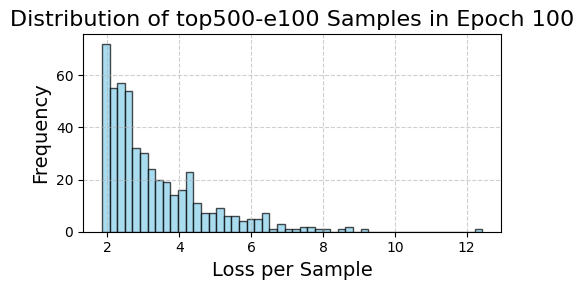

📊 Loss 分布统计:
   样本总数: 500
   平均 Loss: 3.2792
   中位数 Loss: 2.7471
   最小 Loss: 1.8506
   最大 Loss: 12.4328
   标准差: 1.4352


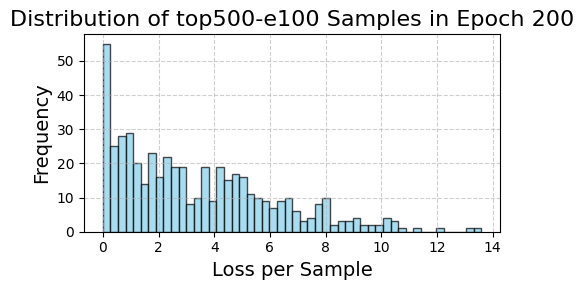

📊 Loss 分布统计:
   样本总数: 500
   平均 Loss: 3.3475
   中位数 Loss: 2.7042
   最小 Loss: 0.0001
   最大 Loss: 13.5940
   标准差: 2.7630


In [10]:
def plot_loss_distribution(
    model: torch.nn.Module,
    ds,
    batch_size: int = 512,
    title: str = "Loss Distribution",
    bins: int = 50,
    figsize: tuple = (5, 3),
    device = 'cuda'
):
    """
    绘制模型在给定数据集上每个样本的损失值分布直方图。
    """
    model.eval()  # 确保模型处于评估模式

    # 创建 DataLoader
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

    all_losses = []

    # 使用无 reduction 的损失函数（逐样本计算）
    criterion = torch.nn.CrossEntropyLoss(reduction='none')  # 假设是分类任务

    with torch.no_grad():
        for batch in dl:
            # 假设 batch 是 (inputs, labels) 格式
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            losses = criterion(outputs, labels)  # shape: [batch_size]
            all_losses.extend(losses.cpu().numpy())

    # 转换为 numpy 数组便于绘图
    import numpy as np
    all_losses = np.array(all_losses)

    # 绘图
    plt.figure(figsize=figsize)
    plt.hist(all_losses, bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(title, fontsize=16)
    plt.xlabel('Loss per Sample', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # 可选：打印统计信息
    print(f"📊 Loss 分布统计:")
    print(f"   样本总数: {len(all_losses)}")
    print(f"   平均 Loss: {all_losses.mean():.4f}")
    print(f"   中位数 Loss: {np.median(all_losses):.4f}")
    print(f"   最小 Loss: {all_losses.min():.4f}")
    print(f"   最大 Loss: {all_losses.max():.4f}")
    print(f"   标准差: {all_losses.std():.4f}")

test_top500_e100_indices = np.load('test_top500_e100_indices.npy')
hloss_ds = Subset(test_ds, test_top500_e100_indices)
plot_loss_distribution(model100, hloss_ds, title='Distribution of top500-e100 Samples in Epoch 100')
model200.to('cuda')
plot_loss_distribution(model200, hloss_ds, title='Distribution of top500-e100 Samples in Epoch 200')

#### plot normal training

In [11]:
def copy_model(original_model, ds_name='cifar10', model_name='resnet20'):
	model = get_model(ds_name, model_name, weights=None, num_classes=10)
	model.load_state_dict(original_model.state_dict())
	model.to('cuda')

	return model

def make_cont_train_curve_fn(
	model,
	train_subds,
	lr=0.05,
	total_samples=5*len(train_ds),    # 总训练样本数
	eval_interval=0.5*len(train_ds),    # 每多少样本评估一次
	momentum=0.9,
	include_init=True,       # 是否包含初始状态（0 样本时）
	test_subds=test_subds
):
	"""
	在固定总样本数下训练，分阶段评估，用于公平比较不同子集。
	返回 fn(seed) -> { 'train_loss': [...], 'test_loss': [...], 'test_sub_loss': [...] }
	"""
	def train_fn(seed):
		set_seed(seed)
		local_model = copy_model(model)
		optimizer = SGD(local_model.parameters(), lr=lr, momentum=momentum, weight_decay=5e-4)
		
		# 准备数据迭代器
		train_subdl = DataLoader(train_subds, batch_size=512, shuffle=True, num_workers=0)
		data_iter = iter(train_subdl)
		
		results = {k: [] for k in ['train_loss', 'test_loss', 'test_sub_loss']}
		
		# 初始评估
		train_dl = DataLoader(train_ds, batch_size=512, shuffle=True, num_workers=0)
		test_subdl = DataLoader(test_subds, batch_size=512, shuffle=True, num_workers=0)
		if include_init:
			for key, dl in zip(results.keys(), [train_dl, test_dl, test_subdl]):
				loss, _ = evaluate_model(local_model, dl)
				results[key].append(loss)
		
		# 分阶段训练
		samples_done = 0
		print(samples_done)
		
		while samples_done < total_samples:
			stage_target = min(eval_interval, total_samples - samples_done)
			stage_done = 0
			
			while stage_done < stage_target:
				try:
					batch = next(data_iter)
				except StopIteration:
					data_iter = iter(train_subdl)
					batch = next(data_iter)
				
				bs = batch[0].size(0) if isinstance(batch, (list, tuple)) else batch.size(0)
				
				with contextlib.redirect_stdout(io.StringIO()):
					train_one_batch(local_model, batch, optimizer)
				
				stage_done += bs
				samples_done += bs
			
			# 本阶段结束，评估
			for key, dl in zip(results.keys(), [train_subdl, test_dl, test_subdl]):
				loss, _ = evaluate_model(local_model, dl)
				results[key].append(loss)
			
			print(samples_done, results)
		
		return results
	
	return train_fn


def analyze_multi_stage_runs(
    target_func: Callable[[int], Dict[str, List[float]]],
    repeat_num: int = 10,
    max_stages: int = None  # 可选：限制最多分析多少阶段，None = 无限制
) -> Dict[str, np.ndarray]:
    """
    运行 target_func 多次（每次传入不同 seed），
    收集每个阶段（stage）的 loss，计算平均值，
    返回 dict of ndarray，shape=(num_stages,)
    """
    # 第一次运行，获取结构和阶段数
    sample_output = target_func(0)
    keys = list(sample_output.keys())
    num_stages_actual = len(sample_output[keys[0]])  # 假设所有 key 长度一致

    # 如果设置了 max_stages，取较小值
    if max_stages is not None:
        num_stages = min(max_stages, num_stages_actual)
    else:
        num_stages = num_stages_actual

    # 初始化收集器：每个 key 对应一个二维列表 [stage][repeat]
    stage_results = defaultdict(lambda: [[] for _ in range(num_stages)])
    
    # 第一次的结果也要加入统计（上面只用了它来探测结构）
    for key, stage_values in sample_output.items():
        for stage_idx, value in enumerate(stage_values[:num_stages]):  # 截断到 num_stages
            stage_results[key][stage_idx].append(value)

    # 剩余 repeat_num - 1 次运行
    for i in tqdm(range(1, repeat_num), desc="Running repeats"):
        output_dict = target_func(i)
        for key, stage_values in output_dict.items():
            for stage_idx, value in enumerate(stage_values[:num_stages]):  # 同样截断
                stage_results[key][stage_idx].append(value)
    
    # 转换为 ndarray 平均值
    final_results = {}
    for key, stage_lists in stage_results.items():
        averages = [np.mean(values) for values in stage_lists]
        final_results[key] = np.array(averages)
    
    return final_results

In [ ]:
# 1. 构造多 epoch 训练函数
multi_train_fn = make_cont_train_curve_fn(
	model=model100,
	train_subds=train_ds,
	lr=0.05,
)

# 2. 分析多次运行
results_dict = analyze_multi_stage_runs(
	target_func=multi_train_fn,
	repeat_num=10
)

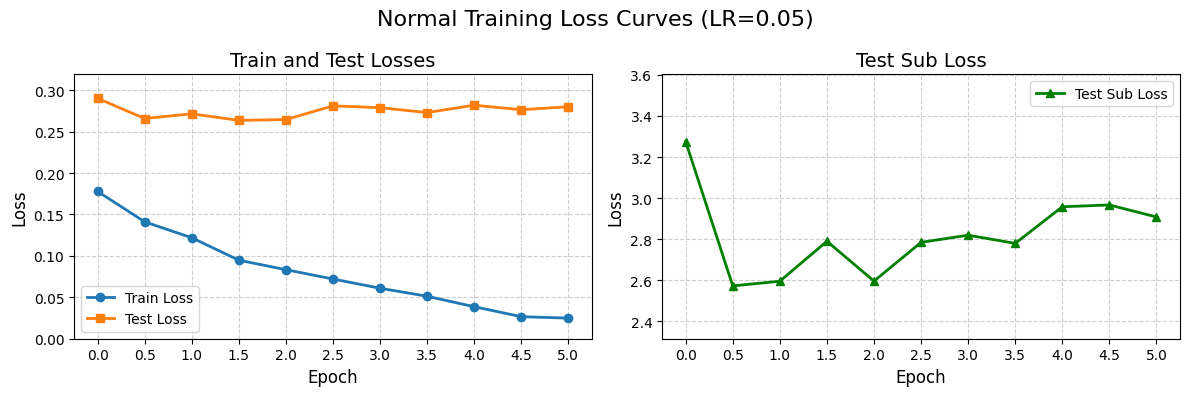

{'train_loss': [0.17784367995262146, 0.1410971928834915, 0.1218765637588501, 0.09477578934669495, 0.08332547618627548, 0.07210285425186157, 0.06092038222193718, 0.051256503247022626, 0.038661433967351916, 0.02661241720318794, 0.02485323562383652], 'test_loss': [0.29008910851478575, 0.26578320298194885, 0.2714660212993622, 0.26352498648166656, 0.2645266917705536, 0.2810440327644348, 0.278873992061615, 0.2729335593223572, 0.2818593379020691, 0.2763371033191681, 0.2800218494415283], 'test_sub_loss': [3.275315284729004, 2.5728888511657715, 2.595473051071167, 2.7902114391326904, 2.5961546897888184, 2.7848315238952637, 2.8197150230407715, 2.77978777885437, 2.958085298538208, 2.966841459274292, 2.90836238861084]}


In [12]:
def plot_training_losses(results_dict: dict, 
                        title: str = "Training Losses over Epochs",
                        figsize: tuple = (12, 4),
                        epoch_interval=0.5):
    """
    分别绘制不同范围的损失曲线
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    epochs = [i * epoch_interval for i in np.arange(0, len(results_dict['train_loss']))]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # 左图：显示 train_loss 和 test_loss（较低范围）
    ax1.plot(epochs, results_dict['train_loss'], 
             marker='o', label='Train Loss', linewidth=2, markersize=6)
    ax1.plot(epochs, results_dict['test_loss'], 
             marker='s', label='Test Loss', linewidth=2, markersize=6)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Train and Test Losses', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.set_ylim(0, max(max(results_dict['train_loss']), max(results_dict['test_loss'])) * 1.1)
    ax1.set_xticks(epochs)

    # 右图：显示 test_sub_loss（较高范围）
    ax2.plot(epochs, results_dict['test_sub_loss'], 
             marker='^', label='Test Sub Loss', linewidth=2, markersize=6, color='green')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Test Sub Loss', fontsize=14)
    ax2.legend(fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.6)
    min_val = min(results_dict['test_sub_loss'])
    max_val = max(results_dict['test_sub_loss'])
    ax2.set_ylim(min_val * 0.9, max_val * 1.1)  # 留一点边距
    ax2.set_xticks(epochs)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

results_dict = {'train_loss': [0.17784367995262146, 0.1410971928834915, 0.1218765637588501, 0.09477578934669495, 0.08332547618627548, 0.07210285425186157, 0.06092038222193718, 0.051256503247022626, 0.038661433967351916, 0.02661241720318794, 0.02485323562383652], 
 'test_loss': [0.29008910851478575, 0.26578320298194885, 0.2714660212993622, 0.26352498648166656, 0.2645266917705536, 0.2810440327644348, 0.278873992061615, 0.2729335593223572, 0.2818593379020691, 0.2763371033191681, 0.2800218494415283], 
 'test_sub_loss': [3.275315284729004, 2.5728888511657715, 2.595473051071167, 2.7902114391326904, 2.5961546897888184, 2.7848315238952637, 2.8197150230407715, 2.77978777885437, 2.958085298538208, 2.966841459274292, 2.90836238861084]}
plot_training_losses(results_dict, title="Normal Training Loss Curves (LR=0.05)")
print(results_dict)

In [ ]:
# 1. 构造多 epoch 训练函数
multi_train_fn = make_cont_train_curve_fn(
	model=model100,
	train_subds=train_ds,
	lr=0.01,
)

# 2. 分析多次运行
results_dict = analyze_multi_stage_runs(
	target_func=multi_train_fn,
	repeat_num=10
)

In [ ]:
plot_training_losses(results_dict, title="Normal Training Loss Curves (LR=0.01)")
print(results_dict)

#### plot mixed training

In [13]:
def make_cont_train_mixed_fn(
    model,  # 👈 直接传入已复制的模型
    original_indices: np.ndarray,
    train_dataset=train_ds,
    test_subds=test_subds,
    lr: float = 0.05,
    total_samples: int = 5*len(train_ds),
    random_ratio: float = 0.0,
	momentum=0.9,
    seed: int = 42
):
    
    set_seed(seed)
    model = copy_model(model)

    n_orig = len(original_indices)
    n_random = int(total_samples * random_ratio)
    n_repeat_orig = total_samples - n_random

    repeated_orig_indices = np.tile(original_indices, (n_repeat_orig // n_orig + 1))[:n_repeat_orig]
    random_indices = np.random.choice(np.arange(len(train_dataset)), size=n_random, replace=True)
    combined_indices = np.concatenate([repeated_orig_indices, random_indices])

    mixed_train_subds = Subset(train_dataset, combined_indices)

    return make_cont_train_curve_fn(
        model=model,  # 👈 模型在这里绑定
        train_subds=mixed_train_subds,
        test_subds=test_subds,
        total_samples=total_samples,
        lr=lr,
        momentum=momentum,
    )

##### 找rand ratio

In [ ]:
train_indices_arrs = np.load('train_indices_arrs.npy')
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)

random_ratios = [0.0, 0.5, 0.8, 0.9]

multi_cls30_mixed_train_fn_list = \
	[make_cont_train_mixed_fn(model100, original_indices=train_subds.indices, 
						  	 train_dataset=train_ds,lr=0.05, random_ratio=rand_ratio) 
		for rand_ratio in random_ratios ]

# 2. 分析多次运行
cls30_results_dict_list = \
	[analyze_multi_stage_runs(target_func=multi_cls30_mixed_train_fn, repeat_num=2,) 
  					for multi_cls30_mixed_train_fn in multi_cls30_mixed_train_fn_list ]

In [ ]:
cls30_results_dict = {'train_loss': [0.17784368547439575, 0.1466845617465973, 0.057925253460168837, 0.02435289086484909, 0.012935646568775177, 0.0077286092755794525, 0.006088688850700855, 0.004977623375058174, 0.004165996117696166, 0.003802251220986247, 0.0034048756182044745], 
 'test_loss': [0.29008910851478575, 0.336983113193512, 0.35243659081459044, 0.3540900237560272, 0.38373733534812926, 0.3830185806751251, 0.3895860164642334, 0.3864222560405731, 0.39563698930740354, 0.40173564081192015, 0.4023042820453644], 
 'test_sub_loss': [3.275315284729004, 2.6155948638916016, 2.6536381244659424, 2.910794973373413, 3.0644798278808594, 3.1287002563476562, 3.1496968269348145, 3.197073459625244, 3.2364957332611084, 3.2465741634368896, 3.262263536453247]}
plot_training_losses(cls30_results_dict, title="Mixed cls30 Training Loss Curves (LR=0.05, rand_ratio=0)")

In [ ]:
cls30_results_dict = {'train_loss': [0.17784368547439575, 0.20129895320129396, 0.12191601235961914, 0.08680833171701431, 0.06066989449596405, 0.05418569926023483, 0.04841889655184746, 0.04741781551873684, 0.028094663883209227, 0.03771534678554535, 0.02533280685776472], 
					  'test_loss': [0.29008910851478575, 0.3192882302761078, 0.28189442210197446, 0.28136772937774657, 0.2784577088832855, 0.28576665840148924, 0.2942238489151001, 0.31522144746780395, 0.29981594247817994, 0.3207595480442047, 0.2993498367071152], 
					  'test_sub_loss': [3.275315284729004, 2.6766574382781982, 2.578464984893799, 2.6968483924865723, 2.7754101753234863, 2.939864158630371, 2.970102071762085, 2.9059066772460938, 3.2237281799316406, 3.3009564876556396, 3.0053980350494385]}
plot_training_losses(cls30_results_dict, title="Mixed cls30 Training Loss Curves (LR=0.05, rand_ratio=0.5)")

In [ ]:
cls30_results_dict = {'train_loss': [0.17784368330478667, 0.14801332925510408, 0.11804205339813233, 0.11128875854349136, 0.08346863263559341, 0.06951319223499298, 0.05764466813468933, 0.0659980989999771, 0.04376467997169495, 0.03893787410521507, 0.03055681682908535], 
						'test_loss': [0.29008910851478575, 0.2670853515625, 0.26949266290664675, 0.28109575300216677, 0.2782585271835327, 0.27187558617591856, 0.27891243200302124, 0.3176679431438446, 0.2946985822200775, 0.2972243812084198, 0.3075075912952423], 
						'test_sub_loss': [3.275315284729004, 2.5915818214416504, 2.679567813873291, 2.7361464500427246, 2.7576324939727783, 2.8138160705566406, 2.956425189971924, 3.0601608753204346, 3.0056076049804688, 2.9261081218719482, 3.1612069606781006]}

plot_training_losses(cls30_results_dict, title="Mixed cls30 Training Loss Curves (LR=0.05, rand_ratio=0.9)")

##### train

In [ ]:
train_indices_arrs = np.load('train_indices_arrs.npy')
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)

multi_cls30_mixed_train_fn = make_cont_train_mixed_fn(model100, original_indices=train_subds.indices, 
						  	 train_dataset=train_ds,lr=0.05, random_ratio=0.8)

# 2. 分析多次运行
cls30_results_dict = analyze_multi_stage_runs(target_func=multi_cls30_mixed_train_fn, repeat_num=10,)

In [ ]:
plot_training_losses(cls30_results_dict, title="Cls30 Training Loss Curves (LR=0.05, Random_ratio=0.8)")
print(cls30_results_dict)

In [ ]:
train_indices_arrs = np.load('train_indices_arrs.npy')
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)

multi_cls30_mixed_train_fn = make_cont_train_mixed_fn(model100, original_indices=train_subds.indices, 
						  	 train_dataset=train_ds,lr=0.01, random_ratio=0.8)

# 2. 分析多次运行
cls30_results_dict = analyze_multi_stage_runs(target_func=multi_cls30_mixed_train_fn, repeat_num=10,)

In [ ]:
plot_training_losses(cls30_results_dict, title="Cls30 Training Loss Curves (LR=0.01, Random_ratio=0.8)")
print(cls30_results_dict)

##### different cls_num one cluster

In [15]:
cls1_train_indices_arrs = np.load("cluster_results/cls1_train_indices_arrs.npy")
cls5_train_indices_arrs = np.load("cluster_results/cls5_train_indices_arrs.npy")
cls10_train_indices_arrs = np.load("cluster_results/cls10_train_indices_arrs.npy")
cls20_train_indices_arrs = np.load("cluster_results/cls20_train_indices_arrs.npy")

def load_cls_original_indices_arrs(path : str):
	data = np.load(path, allow_pickle=True)
	return [data[f"arr_{i}"] for i in range(len(data.files))]

cls1_original_indices_arrs = load_cls_original_indices_arrs("cluster_results/cls1_original_indices_arrs.npz")
cls5_original_indices_arrs = load_cls_original_indices_arrs("cluster_results/cls5_original_indices_arrs.npz")
cls10_original_indices_arrs = load_cls_original_indices_arrs("cluster_results/cls10_original_indices_arrs.npz")
cls20_original_indices_arrs = load_cls_original_indices_arrs("cluster_results/cls20_original_indices_arrs.npz")

0


25088 {'train_loss': [0.17784368547439575, 0.14142237471961974], 'test_loss': [0.29008910851478575, 0.2724096769809723], 'test_sub_loss': [3.2792439460754395, 2.7895874977111816]}
50176 {'train_loss': [0.17784368547439575, 0.14142237471961974, 0.12383698181295395], 'test_loss': [0.29008910851478575, 0.2724096769809723, 0.26754406685829163], 'test_sub_loss': [3.2792439460754395, 2.7895874977111816, 2.7495737075805664]}
75264 {'train_loss': [0.17784368547439575, 0.14142237471961974, 0.12383698181295395, 0.11211308959770203], 'test_loss': [0.29008910851478575, 0.2724096769809723, 0.26754406685829163, 0.2595451859474182], 'test_sub_loss': [3.2792439460754395, 2.7895874977111816, 2.7495737075805664, 2.777060031890869]}
100352 {'train_loss': [0.17784368547439575, 0.14142237471961974, 0.12383698181295395, 0.11211308959770203, 0.10434604887866974], 'test_loss': [0.29008910851478575, 0.2724096769809723, 0.26754406685829163, 0.2595451859474182, 0.260725243473053], 'test_sub_loss': [3.27924394607

Running repeats: 0it [00:00, ?it/s]


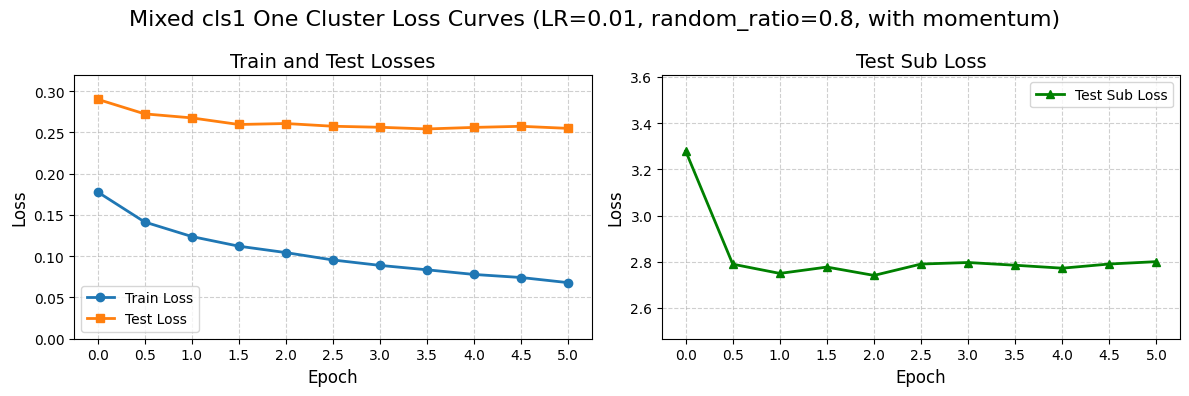

{'train_loss': array([0.17784369, 0.14142237, 0.12383698, 0.11211309, 0.10434605,
       0.09539136, 0.08883703, 0.08348433, 0.07785016, 0.07414646,
       0.06789625]), 'test_loss': array([0.29008911, 0.27240968, 0.26754407, 0.25954519, 0.26072524,
       0.25741296, 0.25616962, 0.25414454, 0.25602072, 0.25735287,
       0.2548242 ]), 'test_sub_loss': array([3.27924395, 2.7895875 , 2.74957371, 2.77706003, 2.74090719,
       2.7901535 , 2.7967813 , 2.78493476, 2.7722187 , 2.79026985,
       2.8005271 ])}


In [16]:
train_sub_indices = cls1_train_indices_arrs[0]
test_subds_one_cls = Subset(test_ds, cls1_original_indices_arrs[0])

# 1. 构造多 epoch 训练函数
train_one_cls_fn = make_cont_train_mixed_fn(
	model=model100,
	original_indices=train_sub_indices,
	test_subds=test_subds_one_cls,
	lr=0.01,
	total_samples=len(train_ds)*5,
	random_ratio=0.8
)

# 2. 分析多次运行
results_dict = analyze_multi_stage_runs(
	target_func=train_one_cls_fn,
	repeat_num=1
)

plot_training_losses(results_dict, 
					 title="Mixed cls1 One Cluster Loss Curves (LR=0.01, random_ratio=0.8, with momentum)")
print(results_dict)

0
25088 {'train_loss': [0.17784368547439575, 0.14548013107299804], 'test_loss': [0.29008910851478575, 0.2580128776550293], 'test_sub_loss': [3.2792439460754395, 2.696884870529175]}
50512 {'train_loss': [0.17784368547439575, 0.14548013107299804, 0.1328364382982254], 'test_loss': [0.29008910851478575, 0.2580128776550293, 0.25358070945739747], 'test_sub_loss': [3.2792439460754395, 2.696884870529175, 2.6669678688049316]}
75600 {'train_loss': [0.17784368547439575, 0.14548013107299804, 0.1328364382982254, 0.12402527518749237], 'test_loss': [0.29008910851478575, 0.2580128776550293, 0.25358070945739747, 0.24885646162033082], 'test_sub_loss': [3.2792439460754395, 2.696884870529175, 2.6669678688049316, 2.620765209197998]}
101024 {'train_loss': [0.17784368547439575, 0.14548013107299804, 0.1328364382982254, 0.12402527518749237, 0.1156847977232933], 'test_loss': [0.29008910851478575, 0.2580128776550293, 0.25358070945739747, 0.24885646162033082, 0.24573825833797455], 'test_sub_loss': [3.279243946075

Running repeats: 0it [00:00, ?it/s]


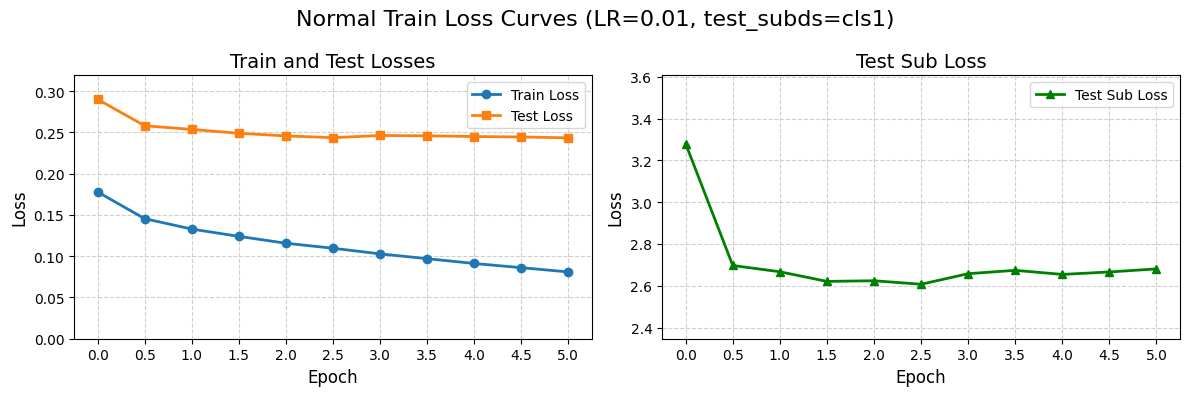

{'train_loss': array([0.17784369, 0.14548013, 0.13283644, 0.12402528, 0.1156848 ,
       0.10964003, 0.10278183, 0.09698425, 0.09115398, 0.08607533,
       0.08090186]), 'test_loss': array([0.29008911, 0.25801288, 0.25358071, 0.24885646, 0.24573826,
       0.24357974, 0.24622264, 0.24586142, 0.24496015, 0.24442331,
       0.24337558]), 'test_sub_loss': array([3.27924395, 2.69688487, 2.66696787, 2.62076521, 2.62384701,
       2.60709643, 2.65770698, 2.67371511, 2.65418434, 2.66600299,
       2.68059826])}


In [34]:
multi_train_fn = make_cont_train_curve_fn(
	model=model100,
	train_subds=train_ds,
	lr=0.01,
	test_subds=test_subds_one_cls
)

results_dict = analyze_multi_stage_runs(
	target_func=multi_train_fn,
	repeat_num=1
)

plot_training_losses(results_dict, 
					 title="Normal Train Loss Curves (LR=0.01, test_subds=cls1)")
print(results_dict)

0
25088 {'train_loss': [0.17784368547439575, 0.1347495793533325], 'test_loss': [0.29008910851478575, 0.2725038996219635], 'test_sub_loss': [3.3724935054779053, 2.0694797039031982]}
50176 {'train_loss': [0.17784368547439575, 0.1347495793533325, 0.11752513639068604], 'test_loss': [0.29008910851478575, 0.2725038996219635, 0.25902998919486997], 'test_sub_loss': [3.3724935054779053, 2.0694797039031982, 2.2345688343048096]}
75264 {'train_loss': [0.17784368547439575, 0.1347495793533325, 0.11752513639068604, 0.10822378558588028], 'test_loss': [0.29008910851478575, 0.2725038996219635, 0.25902998919486997, 0.25686746158599855], 'test_sub_loss': [3.3724935054779053, 2.0694797039031982, 2.2345688343048096, 2.317713737487793]}
100352 {'train_loss': [0.17784368547439575, 0.1347495793533325, 0.11752513639068604, 0.10822378558588028, 0.10133396127986909], 'test_loss': [0.29008910851478575, 0.2725038996219635, 0.25902998919486997, 0.25686746158599855, 0.2558469965457916], 'test_sub_loss': [3.3724935054

Running repeats: 0it [00:00, ?it/s]


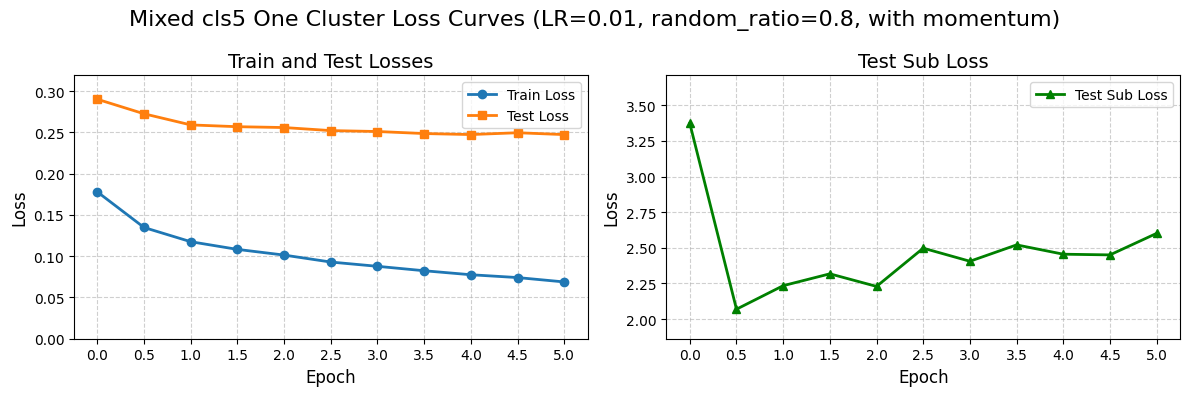

{'train_loss': array([0.17784369, 0.13474958, 0.11752514, 0.10822379, 0.10133396,
       0.0928994 , 0.0877205 , 0.08235986, 0.07751494, 0.07409818,
       0.06879539]), 'test_loss': array([0.29008911, 0.2725039 , 0.25902999, 0.25686746, 0.255847  ,
       0.25214722, 0.25103838, 0.24857425, 0.24734267, 0.24955143,
       0.24729314]), 'test_sub_loss': array([3.37249351, 2.0694797 , 2.23456883, 2.31771374, 2.22937179,
       2.49762344, 2.40576553, 2.5206666 , 2.45524573, 2.45041943,
       2.60149598])}


In [35]:
train_sub_indices = cls5_train_indices_arrs[0]
test_subds_five_cls = Subset(test_ds, cls5_original_indices_arrs[0])

# 1. 构造多 epoch 训练函数
train_five_cls_fn = make_cont_train_mixed_fn(
	model=model100,
	original_indices=train_sub_indices,
	test_subds=test_subds_five_cls,
	lr=0.01,
	total_samples=len(train_ds)*5,
	random_ratio=0.8
)

# 2. 分析多次运行
results_dict = analyze_multi_stage_runs(
	target_func=train_five_cls_fn,
	repeat_num=1
)

plot_training_losses(results_dict, 
					 title="Mixed cls5 One Cluster Loss Curves (LR=0.01, random_ratio=0.8, with momentum)")
print(results_dict)

0
25088 {'train_loss': [0.17784368547439575, 0.14548013107299804], 'test_loss': [0.29008910851478575, 0.2580128776550293], 'test_sub_loss': [3.3724935054779053, 2.7200396060943604]}
50512 {'train_loss': [0.17784368547439575, 0.14548013107299804, 0.1328364382982254], 'test_loss': [0.29008910851478575, 0.2580128776550293, 0.25358070945739747], 'test_sub_loss': [3.3724935054779053, 2.7200396060943604, 2.6760714054107666]}
75600 {'train_loss': [0.17784368547439575, 0.14548013107299804, 0.1328364382982254, 0.12402527518749237], 'test_loss': [0.29008910851478575, 0.2580128776550293, 0.25358070945739747, 0.24885646162033082], 'test_sub_loss': [3.3724935054779053, 2.7200396060943604, 2.6760714054107666, 2.669342279434204]}
101024 {'train_loss': [0.17784368547439575, 0.14548013107299804, 0.1328364382982254, 0.12402527518749237, 0.1156847977232933], 'test_loss': [0.29008910851478575, 0.2580128776550293, 0.25358070945739747, 0.24885646162033082, 0.24573825833797455], 'test_sub_loss': [3.372493505

Running repeats: 0it [00:00, ?it/s]


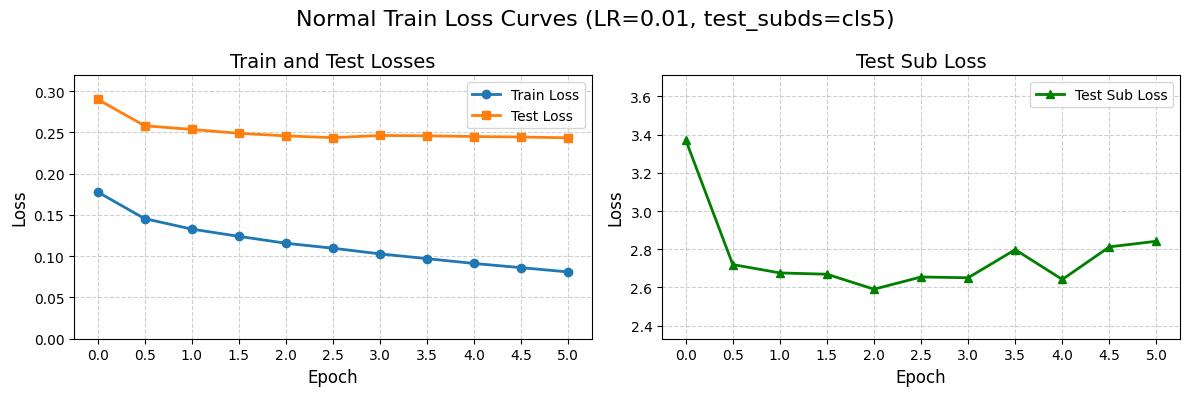

{'train_loss': array([0.17784369, 0.14548013, 0.13283644, 0.12402528, 0.1156848 ,
       0.10964003, 0.10278183, 0.09698425, 0.09115398, 0.08607533,
       0.08090186]), 'test_loss': array([0.29008911, 0.25801288, 0.25358071, 0.24885646, 0.24573826,
       0.24357974, 0.24622264, 0.24586142, 0.24496015, 0.24442331,
       0.24337558]), 'test_sub_loss': array([3.37249351, 2.72003961, 2.67607141, 2.66934228, 2.59099698,
       2.65484405, 2.65086937, 2.79782724, 2.64189458, 2.8124299 ,
       2.84190178])}


In [36]:
multi_train_fn = make_cont_train_curve_fn(
	model=model100,
	train_subds=train_ds,
	lr=0.01,
	test_subds=test_subds_five_cls
)

results_dict = analyze_multi_stage_runs(
	target_func=multi_train_fn,
	repeat_num=1
)

plot_training_losses(results_dict, 
					 title="Normal Train Loss Curves (LR=0.01, test_subds=cls5)")
print(results_dict)

0
25088 {'train_loss': [0.17784368547439575, 0.15847641860675812], 'test_loss': [0.29008910851478575, 0.28020701808929444], 'test_sub_loss': [3.2675280570983887, 2.318164825439453]}
50176 {'train_loss': [0.17784368547439575, 0.15847641860675812, 0.13425690338039398], 'test_loss': [0.29008910851478575, 0.28020701808929444, 0.2747666614532471], 'test_sub_loss': [3.2675280570983887, 2.318164825439453, 2.3091840744018555]}
75264 {'train_loss': [0.17784368547439575, 0.15847641860675812, 0.13425690338039398, 0.11991794021415711], 'test_loss': [0.29008910851478575, 0.28020701808929444, 0.2747666614532471, 0.26587396378517153], 'test_sub_loss': [3.2675280570983887, 2.318164825439453, 2.3091840744018555, 2.519150972366333]}
100352 {'train_loss': [0.17784368547439575, 0.15847641860675812, 0.13425690338039398, 0.11991794021415711, 0.10998397698688507], 'test_loss': [0.29008910851478575, 0.28020701808929444, 0.2747666614532471, 0.26587396378517153, 0.2666538578033447], 'test_sub_loss': [3.26752805

Running repeats: 0it [00:00, ?it/s]


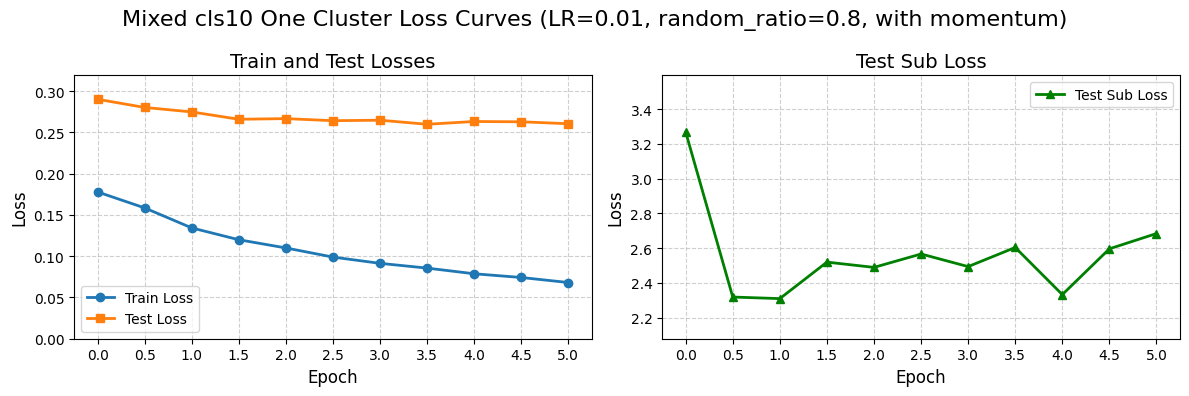

{'train_loss': array([0.17784369, 0.15847642, 0.1342569 , 0.11991794, 0.10998398,
       0.09890035, 0.09132178, 0.08556099, 0.07869013, 0.07418317,
       0.06807595]), 'test_loss': array([0.29008911, 0.28020702, 0.27476666, 0.26587396, 0.26665386,
       0.26414868, 0.26474099, 0.25980773, 0.26318174, 0.2628034 ,
       0.26045845]), 'test_sub_loss': array([3.26752806, 2.31816483, 2.30918407, 2.51915097, 2.48885632,
       2.56599855, 2.49342036, 2.60352921, 2.33229995, 2.59572268,
       2.68366957])}


In [37]:
train_sub_indices = cls10_train_indices_arrs[0]
test_subds_ten_cls = Subset(test_ds, cls10_original_indices_arrs[0])

# 1. 构造多 epoch 训练函数
train_ten_cls_fn = make_cont_train_mixed_fn(
	model=model100,
	original_indices=train_sub_indices,
	test_subds=test_subds_ten_cls,
	lr=0.01,
	total_samples=len(train_ds)*5,
	random_ratio=0.8
)

# 2. 分析多次运行
results_dict = analyze_multi_stage_runs(
	target_func=train_ten_cls_fn,
	repeat_num=1
)

plot_training_losses(results_dict, 
					 title="Mixed cls10 One Cluster Loss Curves (LR=0.01, random_ratio=0.8, with momentum)")
print(results_dict)

0
25088 {'train_loss': [0.17784368547439575, 0.14548013107299804], 'test_loss': [0.29008910851478575, 0.2580128776550293], 'test_sub_loss': [3.2675280570983887, 2.9026589393615723]}
50512 {'train_loss': [0.17784368547439575, 0.14548013107299804, 0.1328364382982254], 'test_loss': [0.29008910851478575, 0.2580128776550293, 0.25358070945739747], 'test_sub_loss': [3.2675280570983887, 2.9026589393615723, 2.7742738723754883]}
75600 {'train_loss': [0.17784368547439575, 0.14548013107299804, 0.1328364382982254, 0.12402527518749237], 'test_loss': [0.29008910851478575, 0.2580128776550293, 0.25358070945739747, 0.24885646162033082], 'test_sub_loss': [3.2675280570983887, 2.9026589393615723, 2.7742738723754883, 2.6279795169830322]}
101024 {'train_loss': [0.17784368547439575, 0.14548013107299804, 0.1328364382982254, 0.12402527518749237, 0.1156847977232933], 'test_loss': [0.29008910851478575, 0.2580128776550293, 0.25358070945739747, 0.24885646162033082, 0.24573825833797455], 'test_sub_loss': [3.26752805

Running repeats: 0it [00:00, ?it/s]


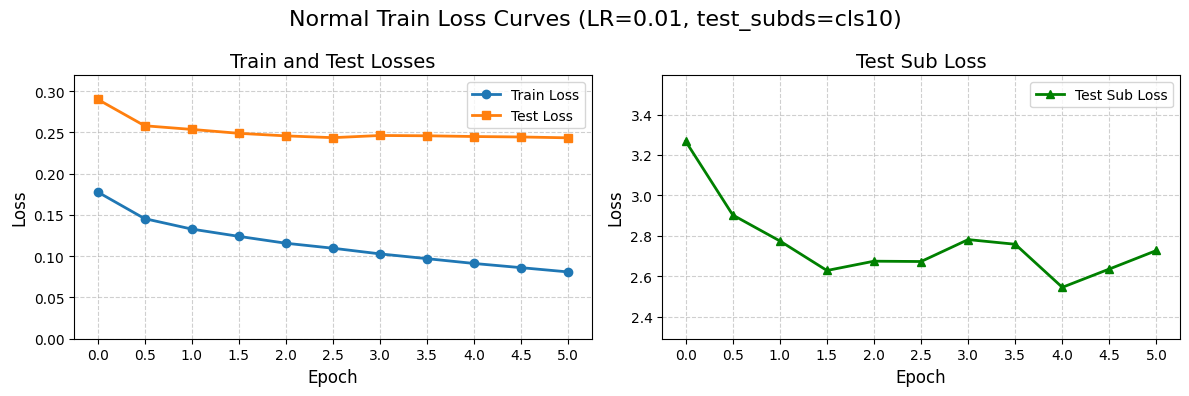

{'train_loss': array([0.17784369, 0.14548013, 0.13283644, 0.12402528, 0.1156848 ,
       0.10964003, 0.10278183, 0.09698425, 0.09115398, 0.08607533,
       0.08090186]), 'test_loss': array([0.29008911, 0.25801288, 0.25358071, 0.24885646, 0.24573826,
       0.24357974, 0.24622264, 0.24586142, 0.24496015, 0.24442331,
       0.24337558]), 'test_sub_loss': array([3.26752806, 2.90265894, 2.77427387, 2.62797952, 2.6740737 ,
       2.67245579, 2.78099918, 2.75790048, 2.54466271, 2.63539696,
       2.72704935])}


In [38]:
multi_train_fn = make_cont_train_curve_fn(
	model=model100,
	train_subds=train_ds,
	lr=0.01,
	test_subds=test_subds_ten_cls
)

results_dict = analyze_multi_stage_runs(
	target_func=multi_train_fn,
	repeat_num=1
)

plot_training_losses(results_dict, 
					 title="Normal Train Loss Curves (LR=0.01, test_subds=cls10)")
print(results_dict)

0


25088 {'train_loss': [0.17784368547439575, 0.14116152045631408], 'test_loss': [0.29008910851478575, 0.2704889654159546], 'test_sub_loss': [3.435941696166992, 2.064112663269043]}
50176 {'train_loss': [0.17784368547439575, 0.14116152045631408, 0.12062197701931], 'test_loss': [0.29008910851478575, 0.2704889654159546, 0.2607494637966156], 'test_sub_loss': [3.435941696166992, 2.064112663269043, 2.0795063972473145]}
75264 {'train_loss': [0.17784368547439575, 0.14116152045631408, 0.12062197701931, 0.11057358787918091], 'test_loss': [0.29008910851478575, 0.2704889654159546, 0.2607494637966156, 0.2589986458778381], 'test_sub_loss': [3.435941696166992, 2.064112663269043, 2.0795063972473145, 2.2269580364227295]}
100352 {'train_loss': [0.17784368547439575, 0.14116152045631408, 0.12062197701931, 0.11057358787918091, 0.10283958869791031], 'test_loss': [0.29008910851478575, 0.2704889654159546, 0.2607494637966156, 0.2589986458778381, 0.2565632053852081], 'test_sub_loss': [3.435941696166992, 2.06411266

Running repeats: 0it [00:00, ?it/s]


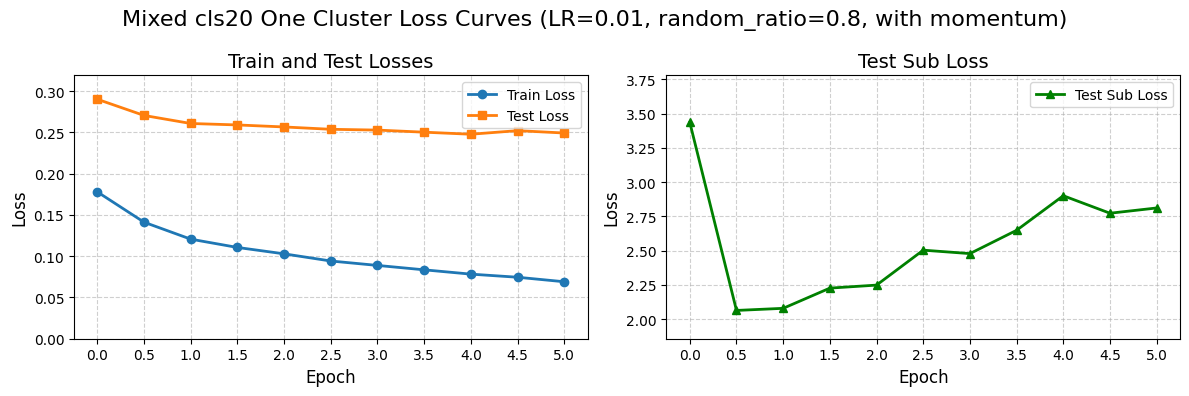

{'train_loss': array([0.17784369, 0.14116152, 0.12062198, 0.11057359, 0.10283959,
       0.09415727, 0.08880083, 0.08347258, 0.07825134, 0.0744897 ,
       0.069018  ]), 'test_loss': array([0.29008911, 0.27048897, 0.26074946, 0.25899865, 0.25656321,
       0.25372519, 0.25276668, 0.25022666, 0.24773572, 0.25208275,
       0.2492137 ]), 'test_sub_loss': array([3.4359417 , 2.06411266, 2.0795064 , 2.22695804, 2.248914  ,
       2.50390863, 2.47880292, 2.64885449, 2.90105224, 2.77336335,
       2.81173491])}


In [39]:
train_sub_indices = cls20_train_indices_arrs[0]
test_subds_twentie_cls = Subset(test_ds, cls20_original_indices_arrs[0])

# 1. 构造多 epoch 训练函数
train_twentie_cls_fn = make_cont_train_mixed_fn(
	model=model100,
	original_indices=train_sub_indices,
	test_subds=test_subds_twentie_cls,
	lr=0.01,
	total_samples=len(train_ds)*5,
	random_ratio=0.8
)

# 2. 分析多次运行
results_dict = analyze_multi_stage_runs(
	target_func=train_twentie_cls_fn,
	repeat_num=1
)

plot_training_losses(results_dict, 
					 title="Mixed cls20 One Cluster Loss Curves (LR=0.01, random_ratio=0.8, with momentum)")
print(results_dict)

0
25088 {'train_loss': [0.17784368547439575, 0.14548013107299804], 'test_loss': [0.29008910851478575, 0.2580128776550293], 'test_sub_loss': [3.435941696166992, 2.9484188556671143]}
50512 {'train_loss': [0.17784368547439575, 0.14548013107299804, 0.1328364382982254], 'test_loss': [0.29008910851478575, 0.2580128776550293, 0.25358070945739747], 'test_sub_loss': [3.435941696166992, 2.9484188556671143, 3.144089937210083]}
75600 {'train_loss': [0.17784368547439575, 0.14548013107299804, 0.1328364382982254, 0.12402527518749237], 'test_loss': [0.29008910851478575, 0.2580128776550293, 0.25358070945739747, 0.24885646162033082], 'test_sub_loss': [3.435941696166992, 2.9484188556671143, 3.144089937210083, 3.1757736206054688]}
101024 {'train_loss': [0.17784368547439575, 0.14548013107299804, 0.1328364382982254, 0.12402527518749237, 0.1156847977232933], 'test_loss': [0.29008910851478575, 0.2580128776550293, 0.25358070945739747, 0.24885646162033082, 0.24573825833797455], 'test_sub_loss': [3.4359416961669

Running repeats: 0it [00:00, ?it/s]


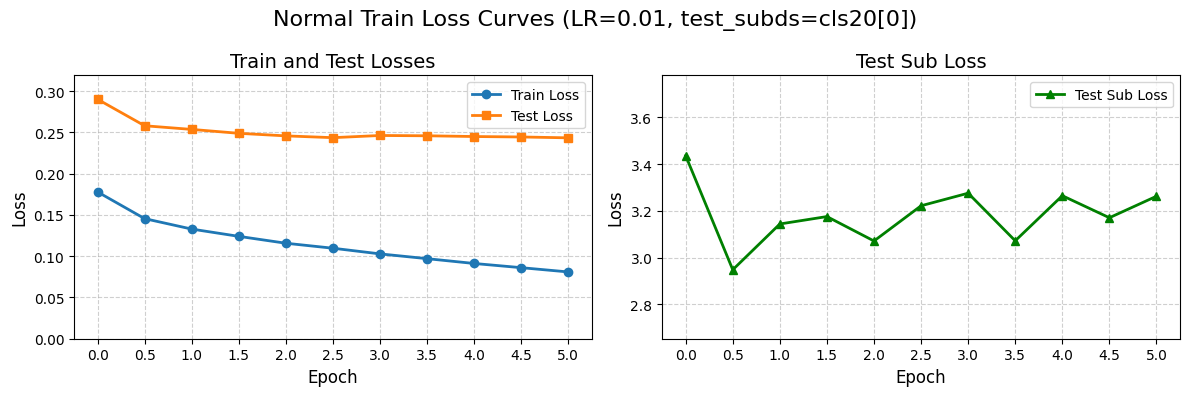

{'train_loss': array([0.17784369, 0.14548013, 0.13283644, 0.12402528, 0.1156848 ,
       0.10964003, 0.10278183, 0.09698425, 0.09115398, 0.08607533,
       0.08090186]), 'test_loss': array([0.29008911, 0.25801288, 0.25358071, 0.24885646, 0.24573826,
       0.24357974, 0.24622264, 0.24586142, 0.24496015, 0.24442331,
       0.24337558]), 'test_sub_loss': array([3.4359417 , 2.94841886, 3.14408994, 3.17577362, 3.07136583,
       3.22196698, 3.27573609, 3.07223439, 3.26500487, 3.17079782,
       3.26262474])}


In [40]:
multi_train_fn = make_cont_train_curve_fn(
	model=model100,
	train_subds=train_ds,
	lr=0.01,
	test_subds=test_subds_twentie_cls
)

results_dict = analyze_multi_stage_runs(
	target_func=multi_train_fn,
	repeat_num=1
)

plot_training_losses(results_dict, 
					 title="Normal Train Loss Curves (LR=0.01, test_subds=cls20[0])")
print(results_dict)

#### plot filtered training

In [ ]:
# num_poisson = 20

not_train_indices = np.load("not_to_train_indices.npy")

bad_indices = set(not_train_indices)  # 转成集合加速查询
all_indices = [i for i in range(len(train_ds)) if i not in bad_indices]

filtered_ds = Subset(train_ds, all_indices)

not_to_train_fn = make_cont_train_curve_fn(model100, filtered_ds, lr=0.01)
filtered_run_results_dict = analyze_multi_stage_runs(
	target_func=not_to_train_fn,
	repeat_num=10
)

In [ ]:
# num_poisson = 20

not_train_indices = np.load("not_to_train_indices.npy")

bad_indices = set(not_train_indices)  # 转成集合加速查询
all_indices = [i for i in range(len(train_ds)) if i not in bad_indices]

filtered_ds = Subset(train_ds, all_indices)

not_to_train_fn = make_cont_train_curve_fn(model100, filtered_ds, lr=0.01)
filtered_run_results_dict = analyze_multi_stage_runs(
	target_func=not_to_train_fn,
	repeat_num=10
)

In [ ]:
plot_training_losses(filtered_run_results_dict, title="Filtered Training Loss Curves (LR=0.01, Filtered=380)")
print(filtered_run_results_dict)

In [ ]:
not_to_train_fn = make_cont_train_curve_fn(model100, filtered_ds, 
										   lr=0.05, )
filtered_run_results_dict = analyze_multi_stage_runs(
	target_func=not_to_train_fn,
	repeat_num=10
)

In [ ]:
plot_training_losses(filtered_run_results_dict, title="Filtered Training Loss Curves (LR=0.05, Filtered=380)")
print(filtered_run_results_dict)

#### plot without momentum

In [ ]:
multi_train_no_momentum_fn = make_cont_train_curve_fn(
	model=model100,
	train_subds=train_ds,
	lr=0.05,
	momentum=0
)

results_dict_no_momentum = analyze_multi_stage_runs(
	target_func=multi_train_no_momentum_fn,
	repeat_num=10
)

In [ ]:
plot_training_losses(results_dict_no_momentum, 
					 title="Normal Training Loss Curves (LR=0.05, without momentum)")
print(results_dict_no_momentum)

In [ ]:
multi_train_no_momentum_fn = make_cont_train_curve_fn(
	model=model100,
	train_subds=train_ds,
	lr=0.01,
	momentum=0
)

results_dict_no_momentum = analyze_multi_stage_runs(
	target_func=multi_train_no_momentum_fn,
	repeat_num=10
)

In [ ]:
plot_training_losses(results_dict_no_momentum, 
					 title="Normal Training Loss Curves (LR=0.01, without momentum)")
print(results_dict_no_momentum)

In [ ]:
not_train_indices = np.load("not_to_train_indices.npy")

bad_indices = set(not_train_indices)  # 转成集合加速查询
all_indices = [i for i in range(len(train_ds)) if i not in bad_indices]

filtered_ds = Subset(train_ds, all_indices)

not_to_train_no_momentum_fn = make_cont_train_curve_fn(model100, filtered_ds, lr=0.05, momentum=0)
filtered_run_results_no_momentum_dict = analyze_multi_stage_runs(
	target_func=not_to_train_no_momentum_fn,
	repeat_num=10
)

In [ ]:
plot_training_losses(filtered_run_results_no_momentum_dict, 
					 title="Filtered Run Training Loss Curves (LR=0.05, without momentum)")
print(filtered_run_results_no_momentum_dict)

In [ ]:
train_indices_arrs = np.load('train_indices_arrs.npy')
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)

multi_cls30_mixed_train_no_momentum_fn = make_cont_train_mixed_fn(model100, original_indices=train_subds.indices, 
						  	 train_dataset=train_ds,lr=0.05, momentum=0,random_ratio=0.8)

# 2. 分析多次运行
cls30_results_no_momentum_dict = analyze_multi_stage_runs\
				(target_func=multi_cls30_mixed_train_no_momentum_fn, repeat_num=10,)

In [ ]:
plot_training_losses(cls30_results_no_momentum_dict, 
					 title="Mixed cls30 Training Loss Curves (LR=0.05, random_ratio=0.8, without momentum)")
print(cls30_results_no_momentum_dict)

In [ ]:
train_indices_arrs = np.load('train_indices_arrs.npy')
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)

multi_cls30_mixed_train_no_momentum_fn = make_cont_train_mixed_fn(model100, original_indices=train_subds.indices, 
						  	 train_dataset=train_ds,lr=0.05, momentum=0,random_ratio=0.0)

# 2. 分析多次运行
cls30_results_no_momentum_dict = analyze_multi_stage_runs\
				(target_func=multi_cls30_mixed_train_no_momentum_fn, repeat_num=10,)

In [ ]:
plot_training_losses(cls30_results_no_momentum_dict, 
					 title="Mixed cls30 Training Loss Curves (LR=0.05, random_ratio=0, without momentum)")
print(cls30_results_no_momentum_dict)

In [ ]:
train_indices_arrs = np.load('train_indices_arrs.npy')
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)

multi_cls30_mixed_train_no_momentum_fn = make_cont_train_mixed_fn(model100, original_indices=train_subds.indices, 
						  	 train_dataset=train_ds,lr=0.01, momentum=0,random_ratio=0.0)

# 2. 分析多次运行
cls30_results_no_momentum_dict = analyze_multi_stage_runs\
				(target_func=multi_cls30_mixed_train_no_momentum_fn, repeat_num=10,)


In [ ]:
plot_training_losses(cls30_results_no_momentum_dict, 
					 title="Mixed cls30 Training Loss Curves (LR=0.01, random_ratio=0, without momentum)")
print(cls30_results_no_momentum_dict)

#### plot one cluster

In [ ]:
train_one_cls_indices = np.load('train_indices_arrs.npy')[0]
train_subds_one_cls = Subset(train_ds, np.load('train_indices_arrs.npy')[0])

test_one_cls_indices = data[f"arr_{0}"]
data = np.load("filtered_cls30_indices_arrs.npz", allow_pickle=True)
test_subds_one_cls = Subset(test_ds, data[f"arr_{0}"])

In [ ]:
# 1. 构造多 epoch 训练函数
multi_train_one_cls_fn = make_cont_train_mixed_fn(
	model=model100,
	original_indices=train_one_cls_indices,
	test_subds=test_subds_one_cls,
	lr=0.05,
	total_samples=len(train_ds)*5,
	random_ratio=0.8
)

# 2. 分析多次运行
results_dict = analyze_multi_stage_runs(
	target_func=multi_train_one_cls_fn,
	repeat_num=1
)

In [ ]:
plot_training_losses(results_dict, 
					 title="Mixed cls30 One Cluster Loss Curves (LR=0.05, random_ratio=0.8, with momentum)")
print(results_dict)

In [ ]:
multi_train_one_cls_fn = make_cont_train_mixed_fn(
	model=model100,
	original_indices=train_one_cls_indices,
	test_subds=test_subds_one_cls,
	lr=0.01,
	total_samples=len(train_ds)*5,
	random_ratio=0.8
)

# 2. 分析多次运行
results_dict = analyze_multi_stage_runs(
	target_func=multi_train_one_cls_fn,
	repeat_num=1
)


In [ ]:
plot_training_losses(results_dict, 
					 title="Mixed cls30 One Cluster Loss Curves (LR=0.01, random_ratio=0.8, with momentum)")
print(results_dict)